In [65]:
import astropy.units as u
import astropy.constants as apc
import cupy as cp
import gala.coordinates as gc
import gala.dynamics as gd
import matplotlib.pyplot as plt
import numpy as np
import os

# from IPython import display
# from scipy.integrate import quad
from astropy.coordinates import Galactocentric
from time import time
from tqdm.notebook import trange

os.environ['CUPY_DUMP_CUDA_SOURCE_ON_ERROR'] = '1'

In [117]:
G = apc.G.to(u.pc**3 / u.yr**2 / u.solMass)  # 4.4985e-15
G_flt = float(G * u.yr**2 * u.solMass / u.pc**3)

milky_way_potential = cp.RawKernel(r'''
extern "C" __global__
void milky_way_potential(const int N, const double q[][3], double a[][3]) {
    double nucl_m = 1.71e9;
    double nucl_a = 0.07e3;
    double bulge_m = 5e9;
    double bulge_a = 1e3;
    double disk_m = 6.8e10;
    double disk_a = 3e3;
    double disk_b = 0.28e3;
    double halo_m = 5.4e11;
    double halo_a = 15.62e3;
    double G = %s;
    
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i >= N)
        return;
    
    double r = sqrt(q[i][0]*q[i][0] + q[i][1]*q[i][1] + q[i][2]*q[i][2]);
    double sqrtz = sqrt(q[i][2]*q[i][2] + disk_b*disk_b);
    double zd = disk_a + sqrtz;
    double tmp = G * disk_m * pow(q[i][0]*q[i][0] + q[i][1]*q[i][1] + zd*zd, -1.5);

    for (int j = 0; j < 3; j++) {
        a[i][j] = -G * nucl_m / (r * (r+nucl_a) * (r+nucl_a)) * q[i][j];
        a[i][j] -= G * bulge_m / (r * (r+bulge_a) * (r+bulge_a)) * q[i][j];
        a[i][j] -= G * halo_m * (log(1 + r/halo_a) - r/(r + halo_a)) / (r*r*r) * q[i][j];

        a[i][j] -= tmp * q[i][j] * ( j==2 ? (1 + disk_a/sqrtz) : 1);
    }
}
''' % G_flt, 'milky_way_potential')


n_body_potential = cp.RawKernel(r'''
extern "C" __global__
void n_body_potential(const int N, const double m[], const double q[][3], double a[][3]) {
    double G = %s;
    
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    int n = blockDim.y * blockIdx.y + threadIdx.y;
    
    if (i >= N or n >= N)
        return;
    
    if (n == i)
        return;

    double r2 = 0;
    for (int k = 0; k < 3; k++)
        r2 += (q[i][k] - q[n][k]) * (q[i][k] - q[n][k]);

    for (int k = 0; k < 3; k++)
        a[i][k] -= G * m[n] * (q[i][k] - q[n][k]) / (r2 * sqrt(r2));
}
''' % G_flt, 'n_body_potential')


def acceleration(N, m, q, a, N_tuple):
    N_blocks, N_threads = N_tuple
    milky_way_potential((N_blocks,), (N_threads,), (N, q, a))
    
    N_blocks, N_threads = int(N_blocks**.5 + 1), int(N_threads**.5 + 1)
    
    n_body_potential((N_blocks, N_blocks), (N_threads, N_threads), (N, m, q, a))
    
    
def time_step(N, m, q, v, dt, N_tuple):
    # position calculation
    a1 = cp.zeros_like(q)
    acceleration(N, m, q, a1, N_tuple)
    q_out = q + v * dt + dt**2/2 * a1
    
    # velocity calculation
    a2 = cp.zeros_like(q)
    acceleration(N, m, q_out, a2, N_tuple)
    v_out = v + dt/2 * (a1 + a2)
    
    return (q_out, v_out)


def evolve(masses, q0, v0, dt, T_max, N_tuple, print_memory=False):
    N_pts = int(T_max/dt)
    N = len(masses)
    N_save = 1000
    
    qs = cp.zeros((int(N_pts/N_save), N, 3))
    vs = cp.zeros((int(N_pts/N_save), N, 3))
    q = cp.array(q0)
    v = cp.array(v0)
    qs[0] = q
    vs[0] = v
    masses = cp.array(masses)
    
    mempool = cp.get_default_memory_pool()
    start_time = time()
    
    for i in trange(N_pts, miniters=2000):
        q, v = time_step(N, masses, q, v, dt, N_tuple)
        
        if i % N_save == N_save-1:
            qs[int(i/N_save)] = q
            vs[int(i/N_save)] = v

        if print_memory and i % 10000 == 0:
            print(f'Used: {mempool.used_bytes()} B; Total: {mempool.total_bytes()} B')

    print(f'Total time: {time() - start_time:.0f}s')
    return (qs, vs)


def energy(masses, qs, vs):
    N = len(masses)
    energy_stability = cp.RawKernel(r'''
    extern "C" __global__
    void energy_stability(const double m[], const double q[][%d][3], const double v[][%d][3],double E[]) {
        double nucl_m = 1.71e9;
        double nucl_a = 0.07e3;
        double bulge_m = 5e9;
        double bulge_a = 1e3;
        double disk_m = 6.8e10;
        double disk_a = 3e3;
        double disk_b = 0.28e3;
        double halo_m = 5.4e11;
        double halo_a = 15.62e3;
        double G = %s;

        int i = blockDim.x * blockIdx.x + threadIdx.x;
        if (i > %d) return;
        E[i] = 0;
        int k;

        for (int j = 0; j < %d; j++) {
            double r = sqrt(q[i][j][0]*q[i][j][0] + q[i][j][1]*q[i][j][1] + q[i][j][2]*q[i][j][2]);
            double sqrtz = sqrt(q[i][j][2]*q[i][j][2] + disk_b*disk_b);
            double zd = disk_a + sqrtz;

            E[i] -= G * m[j] * bulge_m / (r + bulge_a);
            E[i] -= G * m[j] * nucl_m / (r + nucl_a);
            E[i] -= G * m[j] * disk_m / sqrt(q[i][j][0]*q[i][j][0] + q[i][j][1]*q[i][j][1] + zd*zd);
            E[i] -= G * m[j] * halo_m * log(1 + r/halo_a)/r;

            for (k = 0; k < %d; k++) {
                if (k == j) continue;

                double r2 = 0;
                for (int l = 0; l < 3; l++)
                    r2 += (q[i][j][l] - q[i][k][l]) * (q[i][j][l] - q[i][k][l]);

                E[i] -= G * m[j] * m[k] / sqrt(r2);
            }

            for (k = 0; k < 3; k++)
                E[i] += 0.5 * m[j] * v[i][j][k] * v[i][j][k];
        }
    }
    ''' % (N, N, G_flt, len(qs), N, N), 'energy_stability')
    
    Es = cp.zeros(len(qs))
    energy_stability((1000,), (500,), (masses, qs, vs, Es))
    return Es

In [29]:
# testing time evolution on a problem with small N
masses = cp.array([100., 20., 0.7, 4.])
q_init = cp.array([[-3090, 2000, 10],
                   [-3040, 2050, 30],
                   [-3030, 2160, 80],
                   [-3000, 2020, 70]
                  ])
v_init = cp.array([[-1e-9, -2e-4, 1e-4],
                   [-1e-9, -2e-4, 1e-4],
                   [-1e-9, -2e-4, 1e-4],
                   [-1e-9, -2e-4, 1e-4]
                  ])
    
qs, vs = evolve(masses, q_init, v_init, 1e3, 5e8, (1, 4))
Es = cp.asnumpy(energy(masses, qs, vs))

avg = sum(Es)/len(Es)
max_deviation = max(max(Es) - avg, avg - min(Es))/abs(avg)
print(f'Maximum energy deviation of the system: {max_deviation}')

del qs, Es

  0%|          | 0/500000 [00:00<?, ?it/s]

Total time: 81s
Maximum energy deviation of the system: 4.4578567716327584e-14


In [26]:
between = lambda x, a, b: np.where((x >= a) & (x <= b), True, False)  # useful for defining piecewise functions
min_mass = 0.1  # minimum expected star mass
max_mass = 15   # maximum expected star mass
_cint = 0.08**0.7/0.7 + 1/(0.3 * 0.08**0.3)
_norm = 0.08**0.7/0.7 + 1/(0.3 * 0.08**0.3) - 1/(0.3 * 0.5**0.3) + 1/(1.3 * 0.5**1.3) - 1/(1.3 * m_max**1.3)
rng = np.random.default_rng()
# m_exp = (0.08**1.7/1.7 + 0.5**0.7/0.7 - 0.08**0.7/0.7 + 1/(0.3 * 0.5**0.3) - 1/(0.3 * m_max**0.3))/_norm


# initial mass function as per Koupa, 2001 (normalized)
def koupa_pdf(x):
    condlist = [ between(x, 0, 0.08), between(x, 0.08, 0.5), x >= 0.5 ]
    funclist = [ lambda m: 1/m**0.3/_norm, lambda m: 1/m**1.3/_norm, lambda m: 1/m**2.3/_norm ]
    return np.piecewise(x, condlist, funclist)


# cumulative density function obtained from koupa_pdf
def koupa_cdf(x):
    condlist = [ between(x, 0, 0.08), between(x, 0.08, 0.5), x >= 0.5 ]
    funclist = [ lambda m: m**0.7/(0.7*_norm),
                 lambda m: (_cint - 1/(0.3 * m**0.3))/_norm,
                 lambda m: (_norm - 1/(1.3 * m**1.3))/_norm
               ]
    return np.piecewise(x, condlist, funclist)


# inverse of koupa_cdf
# when a variable is randomly generated from 0 to 1 with a uniform distribution,
# applying this function to that variable will result in a variable distributed according to koupa_cdf
def koupa_ppf(x):
    C1 = koupa_cdf(0.08)
    C2 = koupa_cdf(0.5)
    condlist = [ between(x, 0, C1), between(x, C1, C2), x >= C2 ]
    funclist = [ lambda xi: (xi*_norm*0.7)**(1/0.7),
                 lambda xi: 1/(-xi*_norm*0.3 + _cint*0.3)**(1/0.3),
                 lambda xi: 1/(-xi*_norm*1.3 + _norm*1.3)**(1/1.3)
               ]
    return np.piecewise(x, condlist, funclist)


# sanity check function to verify that randomly generated masses follow the desired pdf
def count_masses(masses):
    n_bins = int(np.ceil(max(masses)/1e-3))  # 1e-3 is the bin size
    return np.array([ (masses <= (i+1)*1e-3).sum() for i in range(n_bins) ])/len(masses)



def random_vector(length):
    x1, x2 = rng.random(2)
    z = (1 - 2*x1) * length
    x = np.sqrt(length**2 - z**2) * np.cos(2 * np.pi * x2)
    y = np.sqrt(length**2 - z**2) * np.sin(2 * np.pi * x2)
    return np.array([x, y, z])


def get_random_velocity():
    g = lambda q: q**2 * (1 - q**2)**(7/2)  # the pdf of velocities for objects in a Plummer sphere
    M = 0.1  # a value to use for rejection sampling - has to be higher than the max value of g
    
    while True:
        x1, x2 = rng.random(2)
        if M * x1 < g(x2):
            return x2
        
        
def generate_initial_conditions(N_stars, R_plummer):
    qs = np.zeros((N_stars, 3))
    vs = np.zeros((N_stars, 3))
    masses = koupa_ppf(rng.random(N_stars))
    for i in range(N_stars):
        r = (rng.random()**(-2/3)-1)**(-1/2)  # dimensionless radius, such that a Plummer sphere is generated
        pos = random_vector(r * R_plummer)  # random position given an amplitude

        v_e = 2**(1/2) * (1 + r**2)**(-1/4) * np.sqrt(G_flt*masses.sum() / R_plummer)  # escape velocity at r
        vel = random_vector(get_random_velocity() * v_e)  # random velocity given an amplitude

        qs[i] = pos
        vs[i] = vel
        
    return (masses, qs, vs)


def plummer_cdf(x):
    return (x**3) * (1 + x**2)**(-3/2)


# sanity check function to verify that randomly generated positions result in a plummer sphere
def find_density_curve(masses, qs):
    rs = np.sqrt(qs[:, 0]**2 + qs[:, 1]**2 + qs[:, 2]**2)
    n_bins = int(np.ceil(max(rs)/1e-3))  # 1e-3 is the bin size
    return np.array([ masses[rs <= (i+1)*1e-3].sum() for i in range(n_bins) ])/masses.sum()


# convert from the coordinate frame centered at the center of the globular cluster to the galactocentric frame
# cluster_distance and cluster_velocity are both 3D vectors
def cluster_to_galactocentric(q_init, v_init, cluster_distance, cluster_velocity):
    for i in range(3):
        q_init[:, i] += cluster_distance[i]
        v_init[:, i] += cluster_velocity[i]

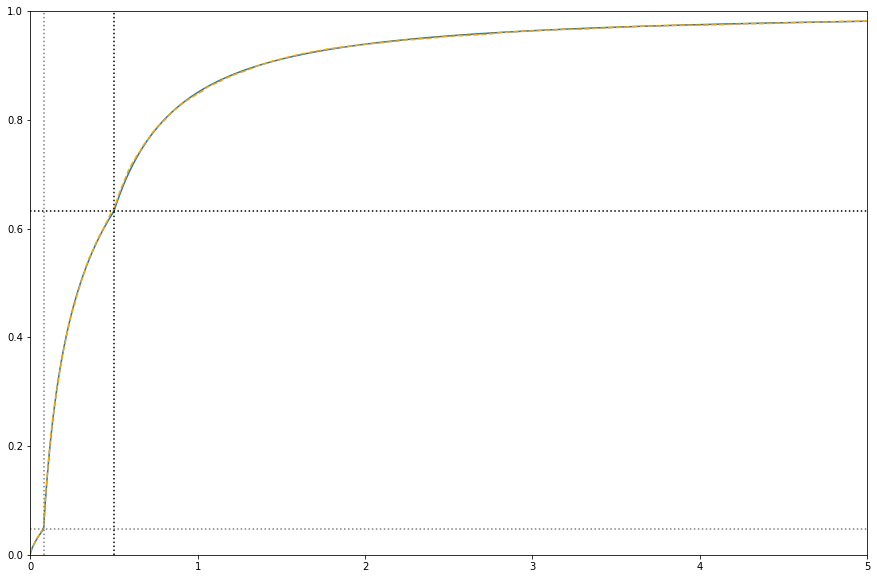

In [27]:
# checking that randomly generated masses follow the Koupa IMF

xs = np.arange(0, 5, 1e-3)
test_masses = koupa_ppf(rng.random(10_000))
mass_distribution = count_masses(test_masses)

plt.figure(figsize=(15, 10))
plt.plot(xs, koupa_cdf(xs))
plt.plot(np.arange(0, max(test_masses), 1e-3), mass_distribution, c='orange', ls='--')

plt.xlim(0, 5)
plt.ylim(0, 1)
plt.axvline(0.08, c='gray', ls=':')
plt.axhline(koupa_cdf(0.08), c='gray', ls=':')
plt.axvline(0.5, c='k', ls=':')
plt.axhline(koupa_cdf(0.5), c='k', ls=':')

del test_masses, mass_distribution

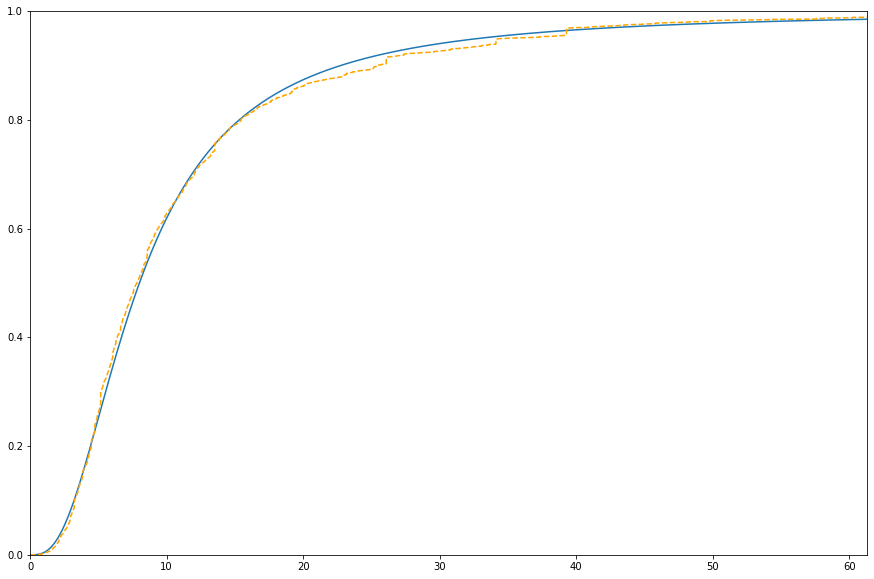

In [28]:
# checking that randomly generated initial conditions result in a Plummer sphere

R = np.sqrt(2**(2/3) - 1) * 8
masses_test, qs_test, _ = generate_initial_conditions(10_000, R)
dc = find_density_curve(masses_test, qs_test)

r_max = np.sqrt(max(qs_test[:, 0]**2 + qs_test[:, 1]**2 + qs_test[:, 2]**2))
xs = np.arange(0, r_max, 1e-3)

plt.figure(figsize=(15, 10))
plt.plot(xs, plummer_cdf(xs/R))
plt.plot(xs, dc, c='orange', ls='--')

plt.xlim(0, 10*R)
plt.ylim(0, 1)

del xs, dc, masses_test, qs_test

In [89]:
# get the current phase space position of the GD1 progenitor and integrate the orbit back 3Gyr
phi1, phi2, d, pm1, pm2, vr = np.load('./data/log_orbit.npy')
c = gc.GD1(phi1=phi1*u.deg, phi2=phi2*u.deg, distance=d*u.kpc,
           pm_phi1_cosphi2=pm1*u.mas/u.yr, pm_phi2=pm2*u.mas/u.yr, radial_velocity=vr*u.km/u.s
          ).transform_to(Galactocentric())

pos_init = [ c.x, c.y, c.z ]
vel_init = [ c.v_x, c.v_y, c.v_z ]

pos_init = cp.array([[ float(q.to(u.pc) / u.pc) for q in pos_init ]])
vel_init = cp.array([[ float(v.to(u.pc/u.yr) * u.yr / u.pc) for v in vel_init ]])
m_ = cp.array([4e7])

qs_cluster, vs_cluster = evolve(m_, pos_init, vel_init, -1e3, -3e9, (1, 1))
qs_cluster, vs_cluster = cp.asnumpy(qs_cluster), cp.asnumpy(vs_cluster)
np.save('./data/GD1_-3Gyr.npy', cluster_pos_vel_3Gyr_ago)

  0%|          | 0/3000000 [00:00<?, ?it/s]

Total time: 478s


In [107]:
cluster_init = np.load('./data/GD1_-3Gyr.npy')
cluster_q0 = cluster_init[:3]
cluster_v0 = cluster_init[3:]

# the Plummer sphere radius scale factor - the last number is the half-mass radius in pc
R = np.sqrt(2**(2/3) - 1) * 8

masses, q_init, v_init = generate_initial_conditions(10_000, R)
cluster_to_galactocentric(q_init, v_init, cluster_q0, cluster_v0)
qs, vs = evolve(masses, q_init, v_init, 1e3, 5e8, (1000, 500))

  0%|          | 0/500000 [00:00<?, ?it/s]

Total time: 280s


In [ ]:
cluster_init = np.load('./data/GD1_-3Gyr.npy')
cluster_q0 = cluster_init[:3]
cluster_v0 = cluster_init[3:]

# the Plummer sphere radius scale factor - the last number is the half-mass radius in pc
R = np.sqrt(2**(2/3) - 1) * 8

masses, q_init, v_init = generate_initial_conditions(10_000, R)
cluster_to_galactocentric(q_init, v_init, cluster_q0, cluster_v0)
qs, vs = evolve(masses, q_init, v_init, 1e3, 5e8, (1000, 500))

In [111]:
start_time = time()
Es = cp.asnumpy(energy(cp.array(masses), cp.array(qs), cp.array(vs)))
print(f'Energy calculated in {time() - start_time:.1f}s')

Energy calculated in 390.2s


In [112]:
max(max(Es) - np.average(Es), np.average(Es) - min(Es))/np.average(Es)

-3.3623539612403114e-05

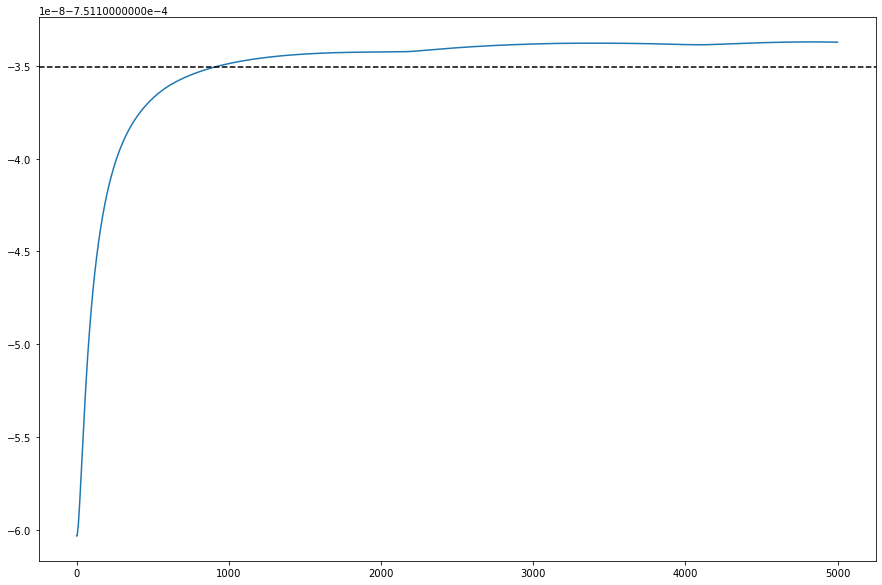

In [113]:
plt.figure(figsize=(15, 10))
plt.plot(Es)
plt.axhline(np.average(Es), c='k', ls='--')

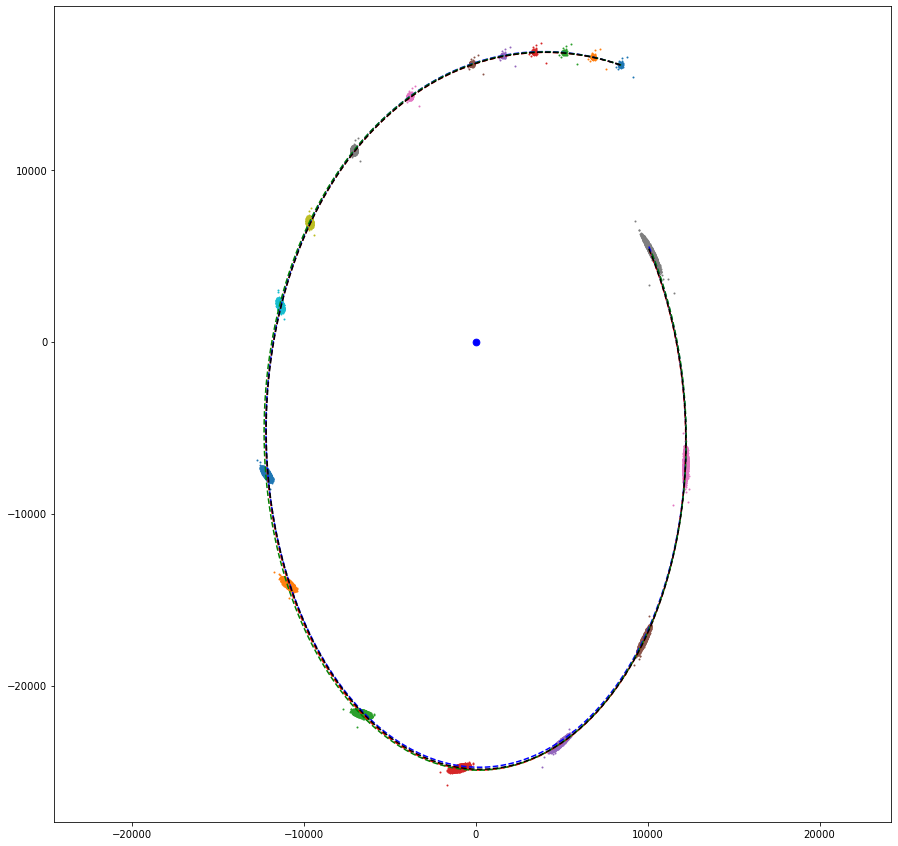

In [110]:
qs = cp.asnumpy(qs)
vs = cp.asnumpy(vs)
plt.figure(figsize=(15, 15))
plt.axis('equal')

time_stamps = [0, 100, 200, 300, 400, 500, 700, 900, 1100, 1300, 1700,
               2000, 2500, 3000, 3500, 4000, 4500, -1]
for t in time_stamps:
    plt.scatter(qs[t, :, 0], qs[t, :, 1], s=1)
    
plt.scatter(0, 0, c='b', s=45)
plt.plot(qs[:, 0, 0], qs[:, 0, 1], 'r--')
plt.plot(qs[:, 1000, 0], qs[:, 1000, 1], 'b--')
plt.plot(qs[:, 2000, 0], qs[:, 2000, 1], 'g--')
plt.plot(qs[:, 3000, 0], qs[:, 3000, 1], 'k--')

In [118]:
q1s, v1s = evolve(masses, qs[-1, :, :], vs[-1, :, :], 1e3, 2.5e9, (1000, 500))

  0%|          | 0/2500000 [00:00<?, ?it/s]

Total time: 1572s


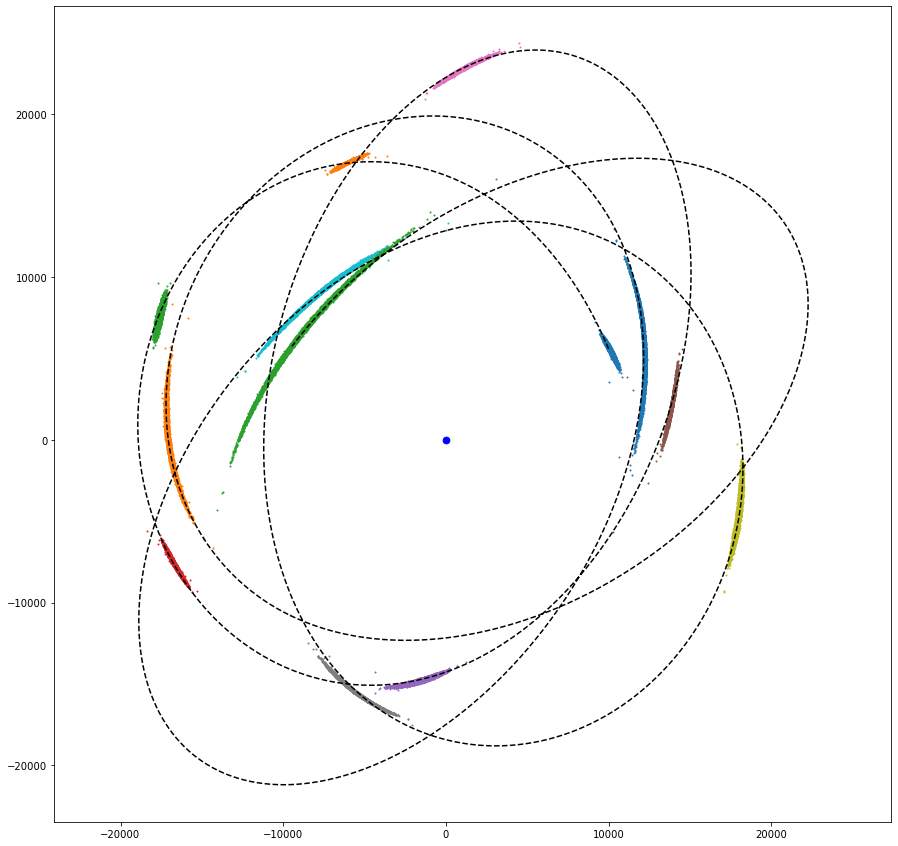

In [122]:
q1s = cp.asnumpy(q1s)
v1s = cp.asnumpy(v1s)
plt.figure(figsize=(15, 15))
plt.axis('equal')

time_stamps = [0, 100, 200, 300, 400, 500, 700, 900, 1100, 1300, 1700,
               2000, -1]
for t in time_stamps:
    plt.scatter(q1s[t, :, 0], q1s[t, :, 1], s=1)
    
plt.scatter(0, 0, c='b', s=45)
plt.plot(q1s[:, 0, 0], q1s[:, 0, 1], 'k--')